<a href="https://colab.research.google.com/github/abelvincentec/PDE-transform-OT/blob/main/LAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Experiment 6: The Inverse Laplace Transform

After analyzing a system or signal in the frequency domain, we often need to return to the time domain to understand the actual physical behavior—how voltage changes, how a robot arm moves, etc. The **Inverse Laplace Transform**, denoted $\mathcal{L}^{-1}\{F(s)\}$, accomplishes this, converting a function $F(s)$ back into its time-domain equivalent, $f(t)$.

### Aim
To compute the Inverse Laplace transform of given s-domain functions and to visualize the connection between the frequency-domain characteristics and the resulting time-domain signal.

### Objectives
*   To use `SymPy` to calculate the inverse Laplace transform of a given function $F(s)$.
*   To analyze the frequency response (magnitude and phase) of the given $F(s)$.
*   To plot the resulting time-domain function $f(t)$.
*   To visually connect features in the frequency domain (like resonant peaks) to behaviors in the time domain (like oscillations).


### Algorithm

1.  **Import Libraries:** Import `sympy`, `numpy`, and `matplotlib.pyplot`.
2.  **Define Symbols:** Declare symbolic variables `s`, `t`, and `w`.
3.  **Define Laplace-Domain Function:** Specify the s-domain function $F(s)$ as a symbolic expression.
4.  **Analyze Frequency Response of F(s):**
    *   Substitute $s = j\omega$ to get the frequency response function $F(j\omega)$.
    *   Lambdify $F(j\omega)$ to prepare for numerical plotting.
    *   Generate a frequency array `w_values` and calculate the magnitude and phase of $F(j\omega)$.
5.  **Compute the Inverse Laplace Transform:**
    *   Use `sp.inverse_laplace_transform(F, s, t)[0]` to find the time-domain function $f(t)$.
    *   Lambdify the resulting symbolic expression $f(t)$.
6.  **Plot and Visualize:** Create a set of plots to show the full picture:
    *   The Magnitude plot of $F(j\omega)$.
    *   The Phase plot of $F(j\omega)$.
    *   The resulting time-domain plot of $f(t)$.
    
    ### Case Study: An Ideal Resonator

**Problem:** You are given the s-domain function $F(s) = \frac{1}{s^2 + 1}$. This is the transfer function of an ideal, undamped second-order system (like a frictionless mass-spring or a lossless LC circuit). Analyze its frequency response and find its impulse response in the time domain by computing the inverse Laplace transform.

**Theoretical Result:** This is the classic transform pair for $\sin(t)$.




The given F(s) is: 1/(s**2 + 1)
The computed Inverse Laplace Transform f(t) is: sin(t)


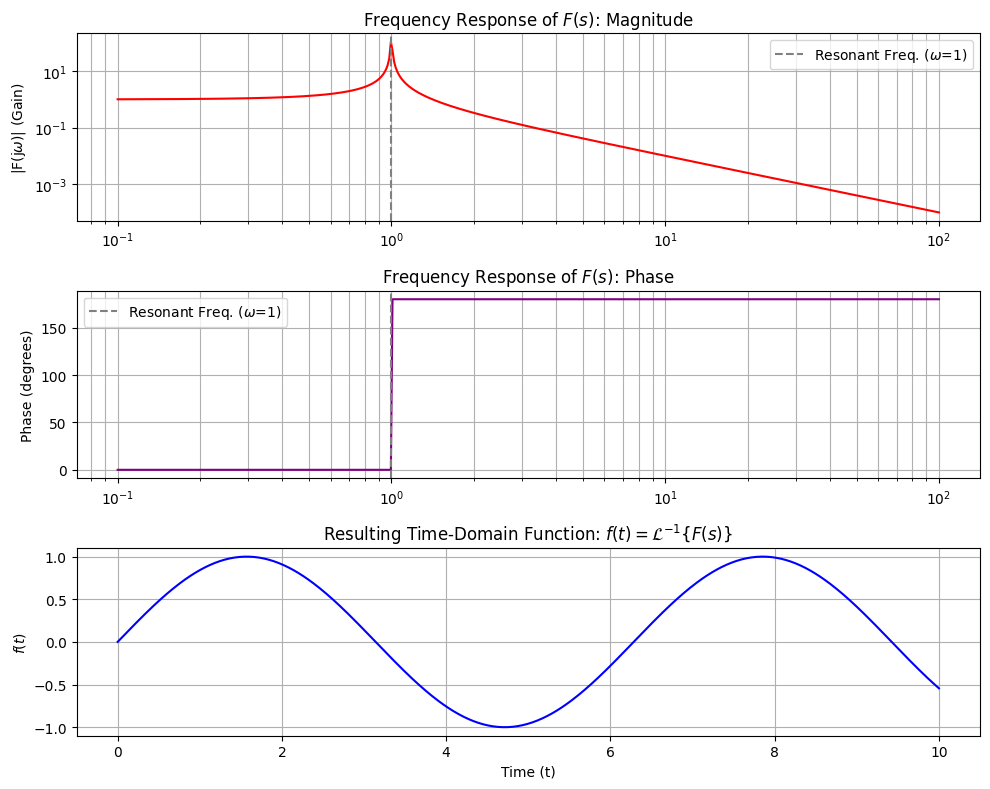

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# --- 1. & 2. Define symbols ---
s, t, w = sp.symbols('s t w', real=True, positive=True)

# --- 3. Define Laplace-domain function ---
F_s = 1 / (s**2 + 1)

# --- 4. Analyze Frequency Response of F(s) ---
F_jw = F_s.subs(s, 1j * w)
F_jw_func = sp.lambdify(w, F_jw, 'numpy')

w_values = np.logspace(-1, 2, 500)
F_jw_values = F_jw_func(w_values)
magnitude = np.abs(F_jw_values)
phase = np.angle(F_jw_values, deg=True)

# --- 5. Compute Inverse Laplace Transform ---
f_t = sp.inverse_laplace_transform(F_s, s, t, noconds=True)
f_t_func = sp.lambdify(t, f_t, 'numpy')

print(f"The given F(s) is: {F_s}")
print(f"The computed Inverse Laplace Transform f(t) is: {f_t}")

# --- 6. Plotting ---
t_values = np.linspace(0, 10, 500)

plt.figure(figsize=(10, 8))

# Plot Magnitude
plt.subplot(3, 1, 1)
plt.loglog(w_values, magnitude, color='red')
plt.title(r'Frequency Response of $F(s)$: Magnitude')
plt.ylabel(r'|F(j$\omega$)| (Gain)')
plt.axvline(x=1, color='gray', linestyle='--', label=r'Resonant Freq. ($\omega$=1)')
plt.grid(True, which="both", ls="-")
plt.legend()

# Plot Phase
plt.subplot(3, 1, 2)
plt.semilogx(w_values, phase, color='purple')
plt.title(r'Frequency Response of $F(s)$: Phase')
plt.ylabel(r'Phase (degrees)')
plt.axvline(x=1, color='gray', linestyle='--', label=r'Resonant Freq. ($\omega$=1)')
plt.grid(True, which="both", ls="-")
plt.legend()

# Plot Time-domain response f(t)
plt.subplot(3, 1, 3)
plt.plot(t_values, f_t_func(t_values), color='blue')
plt.title(r'Resulting Time-Domain Function: $f(t) = \mathcal{L}^{-1}\{F(s)\}$')
plt.xlabel(r'Time (t)')
plt.ylabel(r'$f(t)$')
plt.grid(True)

plt.tight_layout()
plt.show()

#### Results and Discussion

This example provides a perfect illustration of the connection between the frequency and time domains.

- Frequency Domain Analysis: The magnitude plot shows an infinitely sharp resonant peak at $\omega=1$
 rad/s. This tells us the system is extremely sensitive to inputs at this specific frequency and will have a massive response. The phase plot shows an instantaneous 180-degree flip at $\omega=1$, another hallmark of ideal resonance.
- Time Domain Result: The inverse Laplace transform correctly yields $f(t)=sin(t)$. The plot of this function is an undamped sine wave that oscillates forever. This is the time-domain manifestation of the infinite resonant peak seen in the frequency domain. An undamped system, when "hit" by an impulse, will oscillate at its natural frequency indefinitely.

## Application Challenge: Step Response of an RLC Circuit

Problem: Consider a series RLC circuit which is initially at rest (zero initial conditions). A step voltage of 5 volts is applied at $t=0$. Determine the step response of the circuit, i.e., the current
$i(t)$ as a function of time, using the inverse Laplace transform method. Use the following component values:

- Resistance (R): 10 Ω
- Inductance (L): 0.1 H
- Capacitance (C): 0.001 F (1 mF)
>**Circuit Analysis**

For a series RLC circuit, Kirchhoff's Voltage Law (KVL) gives:

$$
L \frac{di(t)}{dt} + R i(t) + \frac{1}{C} \int_0^t i(\tau) \, d\tau = v_s(t)
$$

Taking the Laplace transform of the entire equation (with zero initial conditions):

$$
sLI(s) + RI(s) + \frac{1}{sC}I(s) = V(s)
$$

The input is a step voltage of 5V, so $v_s(t) = 5u(t)$, and its transform is $V(s) = \frac{5}{s}$. Substituting for $V(s)$ and solving for the current $I(s)$:

$$
I(s) \left( sL + R + \frac{1}{sC} \right) = \frac{5}{s} \implies I(s) = \frac{\frac{5}{s}}{sL + R + \frac{1}{sC}}
$$

Simplifying this expression gives us the function we need to find the inverse transform of:

$$
I(s) = \frac{5/L}{s^2 + \frac{R}{L}s + \frac{1}{LC}}
$$

The s-domain expression for the current is I(s) =
         50.0         
──────────────────────
 2                    
s  + 100.0⋅s + 10000.0

The time-domain expression for the current is i(t) =
                   -50.0⋅t                        
0.577350269189626⋅ℯ       ⋅sin(86.6025403784439⋅t)


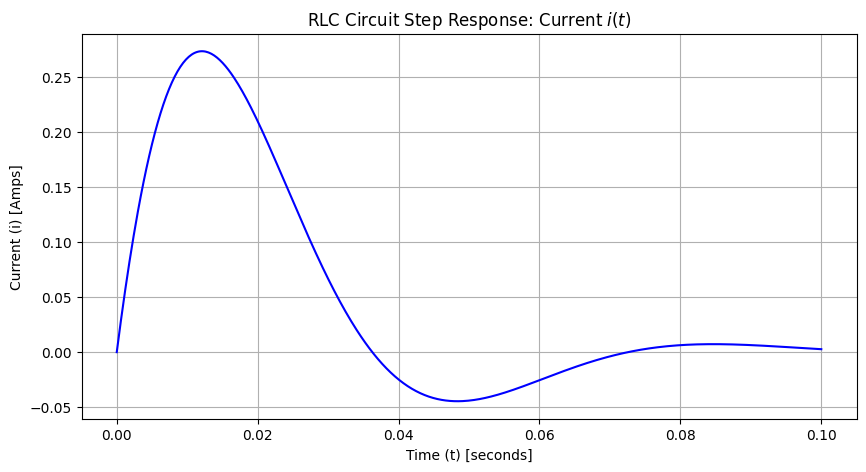

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# --- Define symbols and parameters ---
s, t = sp.symbols('s t', real=True, positive=True)
R_val, L_val, C_val, V_val = 10, 0.1, 0.001, 5

# --- Define the s-domain function I(s) ---
# Derived from the circuit analysis above
I_s = (V_val / L_val) / (s**2 + (R_val / L_val) * s + 1 / (L_val * C_val))
print(f"The s-domain expression for the current is I(s) =")
sp.pprint(I_s)

# --- Compute the Inverse Laplace Transform to find i(t) ---
# <<<<<<<<<<<<<<<<<<<< FIX IS HERE: Add noconds=True <<<<<<<<<<<<<<<<<<<<
i_t = sp.inverse_laplace_transform(I_s, s, t, noconds=True)
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
print("\nThe time-domain expression for the current is i(t) =")
sp.pprint(i_t)

# --- Lambdify for plotting ---
i_t_func = sp.lambdify(t, i_t, 'numpy')

# --- Generate time values and plot ---
t_values = np.linspace(0, 0.1, 500) # The action happens quickly
i_values = i_t_func(t_values)

plt.figure(figsize=(10, 5))
plt.plot(t_values, i_values, color='blue')
plt.title(r'RLC Circuit Step Response: Current $i(t)$')
plt.xlabel(r'Time (t) [seconds]')
plt.ylabel(r'Current (i) [Amps]')
plt.grid(True)
plt.show()

#### Discussion of RLC Circuit Result


The inverse Laplace transform provides the exact analytical solution for the current $i(t)$
in the circuit.

- Underdamped Response: The plot shows a classic underdamped response. When the voltage is applied, the current surges to a peak, overshoots the final steady-state value, and then oscillates with decreasing amplitude until it settles.

- Steady-State Behavior: As $t\to \infty$, the current $i(t)\to 0$. This is physically correct. In a DC circuit, after the initial transient period, the inductor acts like a short circuit (a wire) and the capacitor acts as an open circuit. Since the capacitor blocks the DC current in the steady state, the final current must be zero.

- Connection to System Poles: The oscillatory behavior is due to the complex conjugate poles of the denominator of $I(s)$. If the poles were real and distinct, the response would be overdamped (no oscillation). If the poles were real and repeated, it would be critically damped. This problem beautifully demonstrates how the mathematical properties of $F(s)$ directly dictate the physical nature of $f(t)$.

## Experiment 7: Solving Differential Equations with Laplace Transforms


### Aim

To solve an ordinary differential equation (ODE) using the Laplace Transform method and to visualize the resulting solution.

### Objectives

*   To understand the process of transforming an entire ODE into the s-domain.
*   To solve for the system's response algebraically in the s-domain.
*   To use the Inverse Laplace Transform to bring the solution back into the time domain.
*   To obtain and visualize both the symbolic and numerical solutions.

### Algorithm: The Laplace Transform Method for ODEs

The process follows a clear, three-step "detour" through the s-domain:

1.  **Transform:** Take the Laplace Transform of every term in the differential equation. Use the transform properties for derivatives:
    *   $\mathcal{L}\{y'(t)\} = sY(s) - y(0)$
    *   $\mathcal{L}\{y''(t)\} = s^2Y(s) - sy(0) - y'(0)$
    This step converts the ODE into an algebraic equation in terms of $Y(s)$, automatically incorporating the initial conditions.

2.  **Solve Algebraically:** Rearrange the resulting algebraic equation to solve for $Y(s)$. This $Y(s)$ is the Laplace Transform of the solution to the ODE.

3.  **Inverse Transform:** Apply the Inverse Laplace Transform to $Y(s)$ to find the final solution, $y(t) = \mathcal{L}^{-1}\{Y(s)\}$.

This method elegantly bypasses the need for finding homogeneous and particular solutions, as is done in traditional time-domain methods.


### Case Study: First-Order RC Circuit Model

**Problem:** Using the Laplace Transform, find the solution of the differential equation $y' + y = 1$ with the initial condition $y(0)=0$. This equation models the voltage across a capacitor in a simple RC circuit (with R=1, C=1) connected to a 1V DC source.

**Step-by-Step Solution:**

1.  **Transform the ODE:**
    *   $\mathcal{L}\{y'(t)\} + \mathcal{L}\{y(t)\} = \mathcal{L}\{1\}$
    *   $\left[ sY(s) - y(0) \right] + Y(s) = \frac{1}{s}$

2.  **Incorporate Initial Conditions and Solve for Y(s):**

    *   Since $y(0)=0$, the equation becomes: $sY(s) + Y(s) = \frac{1}{s}$
    *   Factor out $Y(s)$: $Y(s)(s + 1) = \frac{1}{s}$
    *   Solve for $Y(s)$: $Y(s) = \frac{1}{s(s+1)}$

3.  **Inverse Transform:**

    *   Find $y(t) = \mathcal{L}^{-1}\left\{\frac{1}{s(s+1)}\right\}$. This can be done using partial fraction expansion, yielding $y(t) = 1 - e^{-t}$.

Let's verify this process using Python.

The symbolic solution is:


Eq(y(t), 1 - exp(-t))

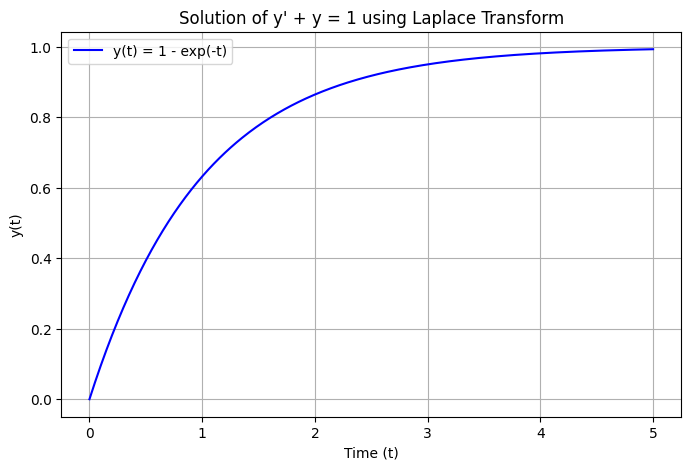

In [3]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Symbols and the ODE ---
t = sp.Symbol('t', positive=True)
s = sp.Symbol('s')
y = sp.Function('y')

# Define the differential equation: y'(t) + y(t) - 1 = 0
ode = y(t).diff(t) + y(t) - 1

# --- 2. Solve directly using SymPy's dsolve with Laplace method ---
# This automates the transform, solve, and inverse transform steps.
# We provide the initial condition y(0)=0 via the 'ics' argument.
solution = sp.dsolve(ode, ics={y(0): 0})

# Display the symbolic solution
print("The symbolic solution is:")
display(solution)
y_t = solution.rhs # Extract the right-hand side for plotting

# --- 3. Visualize the Solution ---
# Convert the symbolic solution into a numerical function for plotting
y_func = sp.lambdify(t, y_t, modules=['numpy'])

# Generate time values for the plot
t_vals = np.linspace(0, 5, 400)
y_vals = y_func(t_vals)

# Plot the result
plt.figure(figsize=(8, 5))
plt.plot(t_vals, y_vals, label=f"y(t) = {y_t}", color='blue')
plt.title("Solution of y' + y = 1 using Laplace Transform")
plt.xlabel("Time (t)")
plt.ylabel("y(t)")
plt.grid(True)
plt.legend()
plt.show()

### Result and Discussion

The solution obtained is $y(t)=1−e^{−t}$. The visualization confirms the behavior described by this function:
The solution curve starts at the point $(0,0)$, satisfying the initial condition $y(0)=0$. As time t increases, the exponential term $e^{−t}$ decays towards zero. Consequently, the solution $y(t)$  asymptotically approaches the value of 1, which is the steady-state response of the system. This behavior is characteristic of a first-order system (like an RC circuit) responding to a step input.

### Application Problem: Mass-Spring-Damper System

In robotics and mechanical engineering, a mass-spring-damper system is a fundamental model for oscillatory behavior, such as a robot arm with flexibility or a vehicle's suspension.
Governing Equation: The motion of the mass $y(t)$ is described by the second-order linear ODE:
$$
my''(t)+cy'(t)+ky(t)=F(t)
$$

Your Task:

Solve for the motion of a system with the following parameters:
- Mass (m): 1 kg
- Damping coefficient (c): 2 Ns/m (This represents friction/drag)
- Spring constant (k): 5 N/m
- External Force (F(t)): 0 (The system is disturbed and then left alone)
- Initial Conditions: The system is pulled from its equilibrium position and released from rest.

Initial position: $y(0)=1$ meter
Initial velocity: $y'(0)=0$ m/s

Use the Laplace Transform method in `SymPy` to find and visualize the displacement $y(t)$.

>Solution to the Application Problem: Mass-Spring-Damper System

We will now solve the second-order ODE for the mass-spring-damper system using the same `sympy.dsolve` method, which internally uses the Laplace transform technique.

**Problem Recap:**

*   **Equation:** $1 \cdot y''(t) + 2 \cdot y'(t) + 5 \cdot y(t) = 0$
*   **Initial Conditions:** $y(0) = 1$, $y'(0) = 0$

**Manual Laplace Transform Steps (for understanding):**

1.  **Transform the ODE:**

    - $\mathcal{L}\{y''\} + 2\mathcal{L}\{y'\} + 5\mathcal{L}\{y\} = \mathcal{L}\{0\}$
    - $\left[s^2Y(s) - sy(0) - y'(0)\right] + 2\left[sY(s) - y(0)\right] + 5Y(s) = 0$
2.  **Incorporate Initial Conditions:**

    - $\left[s^2Y(s) - s(1) - 0\right] + 2\left[sY(s) - 1\right] + 5Y(s) = 0$
    - $s^2Y(s) - s + 2sY(s) - 2 + 5Y(s) = 0$
3.  **Solve for Y(s):**

    - $Y(s)(s^2 + 2s + 5) = s + 2$
    - $Y(s) = \frac{s+2}{s^2 + 2s + 5}$

4.  **Inverse Transform:**

    Find $y(t) = \mathcal{L}^{-1}\left\{ \frac{s+2}{s^2 + 2s + 5} \right\}$. This requires completing the square in the denominator and using the transform pairs for damped sinusoids.

Let's use Python to perform these steps automatically and visualize the result.


The symbolic solution for the system's motion is:


Eq(y(t), (0.5*sin(2.0*t) + 1.0*cos(2.0*t))*exp(-1.0*t))

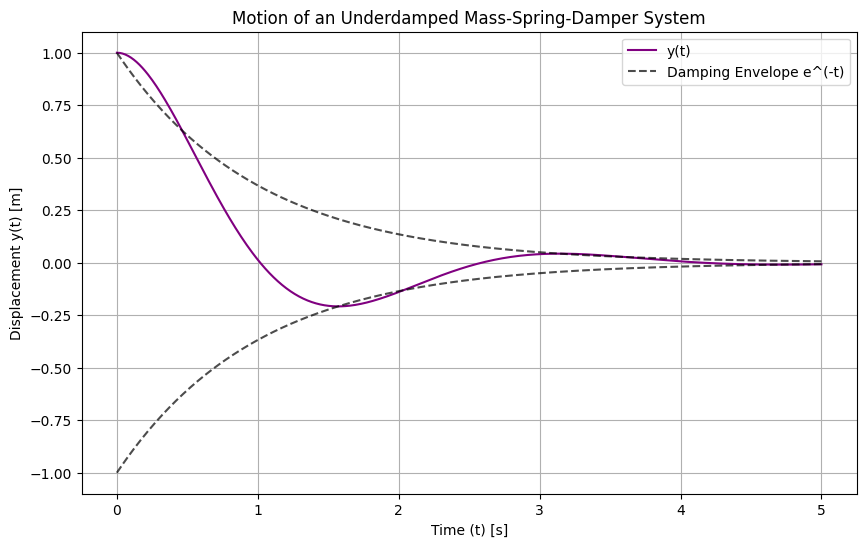

In [4]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Symbols, Function, and Parameters ---
t = sp.Symbol('t', positive=True)
y = sp.Function('y')

# System parameters
m = 1.0
c_damp = 2.0  # Renamed to avoid conflict with sympy's 'c' symbol
k = 5.0

# --- 2. Define and Solve the ODE ---
# Define the differential equation: my'' + cy' + ky = 0
ode = m * y(t).diff(t, 2) + c_damp * y(t).diff(t) + k * y(t)

# Define the initial conditions in a dictionary
# The derivative at t=0 is specified using .subs()
ics = {y(0): 1, y(t).diff(t).subs(t, 0): 0}

# Solve the ODE using dsolve. SymPy automatically handles this structure.
solution = sp.dsolve(ode, ics=ics)

# Display the symbolic solution
print("The symbolic solution for the system's motion is:")
display(solution)
y_t = solution.rhs

# --- 3. Visualize the Solution ---
# Convert the symbolic solution into a numerical function
y_func = sp.lambdify(t, y_t, modules=['numpy'])

# Generate time values for the plot
t_vals = np.linspace(0, 5, 500)
y_vals = y_func(t_vals)

# Plot the result
plt.figure(figsize=(10, 6))
plt.plot(t_vals, y_vals, label=f"y(t)", color='purple')
# Plot an exponential decay envelope to highlight the damping
envelope = np.exp(-t_vals) # From the e^(-t) term in the solution
plt.plot(t_vals, envelope, 'k--', label='Damping Envelope e^(-t)', alpha=0.7)
plt.plot(t_vals, -envelope, 'k--', alpha=0.7)

plt.title("Motion of an Underdamped Mass-Spring-Damper System")
plt.xlabel("Time (t) [s]")
plt.ylabel("Displacement y(t) [m]")
plt.grid(True)
plt.legend()
plt.show()

#### Results and Discussion

Symbolic Solution: The solution obtained is  $y(t)=(\sin(2t)+\cos(2t))e^{−t}$. This mathematical form is characteristic of an underdamped second-order system. It consists of two parts:

- Oscillatory Part: $y(t)=(\sin(2t)+\cos(2t))e^{-t}$ represents the natural oscillation of the mass on the spring. The frequency of this oscillation is $\omega=2$ rad/s.

- Decay Part: $e^{-t}$ is an exponential decay envelope that multiplies the oscillation. This term represents the effect of the damper (friction), which removes energy from the system over time.

- Visual Analysis: The plot clearly visualizes this behavior.

- Initial Conditions: The curve starts at $y=1$ and its initial slope is zero (horizontal), perfectly matching the initial conditions  $y(0)=0$, and $y'(0)=0$.

- Oscillation: The mass oscillates back and forth around its equilibrium position ($y=0$).
Damping: The amplitude of these oscillations is not constant; it progressively decreases over time, confined within the black dashed lines representing the damping envelope. Eventually, the mass will come to rest at $y=0$.

- Engineering Significance: This result is fundamental in control systems and robotics. If this were a robot arm, this "ringing" or oscillation after a command might be undesirable. An engineer would use this model to perhaps increase the damping ($c\_damp$) to achieve a critically damped or overdamped response, where the arm moves to its target position smoothly without overshooting and oscillating. The Laplace Transform method is the cornerstone of this type of analysis.

